In [1]:
"""
================================================================================
DEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES
Recurrent Neural Networks vs Transformers for Time Series Prediction
================================================================================
"""

'\n================================================================================\nDEEP NEURAL NETWORKS - ASSIGNMENT 3: RNN vs TRANSFORMER FOR TIME SERIES\nRecurrent Neural Networks vs Transformers for Time Series Prediction\n================================================================================\n'

STUDENT INFORMATION (REQUIRED - DO NOT DELETE)

BITS ID: [2025aa05288]

Name: [MALI ATMAJA SUDHIR]

Email: [2025aa05288@wilp.bits-pilani.ac.in]

Date: [7th February 2026]

In [2]:
"""
================================================================================
STUDENT INFORMATION (REQUIRED - DO NOT DELETE)
================================================================================

BITS ID: [2025aa05288]
Name: [MALI ATMAJA SUDHIR]
Email: [2025aa05288@wilp.bits-pilani.ac.in]
Date: [8th January 2026]

================================================================================
"""

'\n================================================================================\nSTUDENT INFORMATION (REQUIRED - DO NOT DELETE)\n================================================================================\n\nBITS ID: [2025aa05288]\nName: [MALI ATMAJA SUDHIR]\nEmail: [2025aa05288@wilp.bits-pilani.ac.in]\nDate: [8th January 2026]\n\n================================================================================\n'

In [3]:
"""
================================================================================
ASSIGNMENT OVERVIEW
================================================================================

This assignment requires you to implement and compare two approaches for
time series forecasting:
1. LSTM or GRU using Keras/PyTorch
2. Transformer encoder using Keras/PyTorch layers

Learning Objectives:
- Build recurrent neural networks for sequential data
- Use transformer architecture for time series
- Implement or integrate positional encoding
- Compare RNN vs Transformer architectures
- Understand time series preprocessing and evaluation

IMPORTANT:
- Positional encoding MUST be added to transformer
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Use temporal train/test split (NO shuffling)

================================================================================
"""

'\n================================================================================\nASSIGNMENT OVERVIEW\n================================================================================\n\nThis assignment requires you to implement and compare two approaches for\ntime series forecasting:\n1. LSTM or GRU using Keras/PyTorch\n2. Transformer encoder using Keras/PyTorch layers\n\nLearning Objectives:\n- Build recurrent neural networks for sequential data\n- Use transformer architecture for time series\n- Implement or integrate positional encoding\n- Compare RNN vs Transformer architectures\n- Understand time series preprocessing and evaluation\n\nIMPORTANT:\n- Positional encoding MUST be added to transformer\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Use temporal train/test split (NO shuffling)\n\n================================================================================\n'

In [4]:
"""
================================================================================
⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️
================================================================================

1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb
   Example: 2025AA05036_rnn_assignment.ipynb
   ❌ Wrong filename = Automatic 0 marks

2. STUDENT INFORMATION MUST MATCH:
   ✓ BITS ID in filename = BITS ID in notebook (above)
   ✓ Name in folder = Name in notebook (above)
   ❌ Mismatch = 0 marks

3. EXECUTE ALL CELLS BEFORE SUBMISSION:
   - Run: Kernel → Restart & Run All
   - Verify all outputs are visible
   ❌ No outputs = 0 marks

4. FILE INTEGRITY:
   - Ensure notebook opens without errors
   - Check for corrupted cells
   ❌ Corrupted file = 0 marks

5. IMPLEMENTATION REQUIREMENTS:
   - MUST add positional encoding to transformer (custom or built-in)
   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - DO NOT use pre-trained transformers (HuggingFace, TimeGPT, etc.)
   - DO NOT shuffle time series data (temporal order required)
   ❌ Missing positional encoding = 0 marks for transformer section

6. DATASET REQUIREMENTS:
   - Minimum 1000 time steps
   - Train/test split: 90/10 OR 85/15 (temporal split only)
   - Sequence length: 10-50 time steps
   - Prediction horizon: 1-10 time steps

7. USE KERAS OR PYTORCH:
   - Use framework's LSTM/GRU layers
   - Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
   - Add positional encoding (custom implementation or built-in)
   - Use standard training methods

8. FILE SUBMISSION:
   - Submit ONLY the .ipynb file
   - NO zip files, NO separate data files, NO separate image files
   - All code and outputs must be in the notebook
   - Only one submission attempt allowed

================================================================================
"""

"\n================================================================================\n⚠️ IMPORTANT SUBMISSION REQUIREMENTS - STRICTLY ENFORCED ⚠️\n================================================================================\n\n1. FILENAME FORMAT: <BITS_ID>_rnn_assignment.ipynb\n   Example: 2025AA05036_rnn_assignment.ipynb\n   ❌ Wrong filename = Automatic 0 marks\n\n2. STUDENT INFORMATION MUST MATCH:\n   ✓ BITS ID in filename = BITS ID in notebook (above)\n   ✓ Name in folder = Name in notebook (above)\n   ❌ Mismatch = 0 marks\n\n3. EXECUTE ALL CELLS BEFORE SUBMISSION:\n   - Run: Kernel → Restart & Run All\n   - Verify all outputs are visible\n   ❌ No outputs = 0 marks\n\n4. FILE INTEGRITY:\n   - Ensure notebook opens without errors\n   - Check for corrupted cells\n   ❌ Corrupted file = 0 marks\n\n5. IMPLEMENTATION REQUIREMENTS:\n   - MUST add positional encoding to transformer (custom or built-in)\n   - CAN use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n   - DO 

In [5]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time
import json
import os
import math

Deep learning frameworks (choose Keras or PyTorch)

In [6]:
"""
================================================================================
PART 1: DATASET LOADING AND EXPLORATION (Informational)
================================================================================

Instructions:
1. Choose ONE dataset from the allowed list
2. Load and explore the time series data
3. Fill in ALL required metadata fields below
4. Provide justification for your primary metric choice

ALLOWED DATASETS:
- Stock Prices (daily/hourly closing prices)
- Weather Data (temperature, humidity, pressure)
- Energy Consumption (electricity/power usage)
- Sensor Data (IoT sensor readings)
- Custom time series (with approval)

REQUIRED OUTPUT:
- Print all metadata fields
- Time series plots
- Stationarity analysis
- Train/test split visualization
================================================================================
"""

'\n================================================================================\nPART 1: DATASET LOADING AND EXPLORATION (Informational)\n================================================================================\n\nInstructions:\n1. Choose ONE dataset from the allowed list\n2. Load and explore the time series data\n3. Fill in ALL required metadata fields below\n4. Provide justification for your primary metric choice\n\nALLOWED DATASETS:\n- Stock Prices (daily/hourly closing prices)\n- Weather Data (temperature, humidity, pressure)\n- Energy Consumption (electricity/power usage)\n- Sensor Data (IoT sensor readings)\n- Custom time series (with approval)\n\nREQUIRED OUTPUT:\n- Print all metadata fields\n- Time series plots\n- Stationarity analysis\n- Train/test split visualization\n================================================================================\n'

1.1 Dataset Selection and Loading
TODO: Load your chosen time series dataset

In [7]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os

base_path = "/content/drive/MyDrive/RNN_Dataset"
print("Files in RNN_Dataset folder:")
print(os.listdir(base_path))

Files in RNN_Dataset folder:
['household_power_consumption.txt']


In [9]:
file_path = "/content/drive/MyDrive/RNN_Dataset/household_power_consumption.txt"

df = pd.read_csv(
    file_path,
    sep=';',
    na_values='?',
    low_memory=False
)

print("Dataset loaded successfully")
print(df.head())
print("Shape:", df.shape)

Dataset loaded successfully
         Date      Time  Global_active_power  Global_reactive_power  Voltage  \
0  16/12/2006  17:24:00                4.216                  0.418   234.84   
1  16/12/2006  17:25:00                5.360                  0.436   233.63   
2  16/12/2006  17:26:00                5.374                  0.498   233.29   
3  16/12/2006  17:27:00                5.388                  0.502   233.74   
4  16/12/2006  17:28:00                3.666                  0.528   235.68   

   Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  
0              18.4             0.0             1.0            17.0  
1              23.0             0.0             1.0            16.0  
2              23.0             0.0             2.0            17.0  
3              23.0             0.0             1.0            17.0  
4              15.8             0.0             1.0            17.0  
Shape: (2075259, 9)


In [10]:
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],
    format="%d/%m/%Y %H:%M:%S"
)

df.set_index('Datetime', inplace=True)

print("Datetime index created")
print(df.index[:3])

Datetime index created
DatetimeIndex(['2006-12-16 17:24:00', '2006-12-16 17:25:00',
               '2006-12-16 17:26:00'],
              dtype='datetime64[ns]', name='Datetime', freq=None)


In [11]:
series = df['Global_active_power']

print("Missing values before cleaning:", series.isna().sum())

series = series.dropna()

print("Missing values after cleaning:", series.isna().sum())
print("Final series length:", len(series))


Missing values before cleaning: 25979
Missing values after cleaning: 0
Final series length: 2049280


In [12]:
# REQUIRED: Fill in these metadata fields
dataset_name = "Individual Household Electric Power Consumption"
dataset_source = "UCI Machine Learning Repository"
n_samples = len(series)
n_features = 1
n_features = int(n_features)
sequence_length = 20
sequence_length = int(sequence_length)
prediction_horizon = 1
prediction_horizon = int(prediction_horizon)
problem_type = "time_series_forecasting"

In [13]:
# Primary metric selection
primary_metric = "RMSE"

metric_justification = """
RMSE is chosen because it penalizes larger prediction errors more heavily,
which is important for energy consumption forecasting where sudden spikes
and large deviations are more critical than small errors.
"""

In [14]:
print("\n" + "="*70)
print("DATASET INFORMATION")
print("="*70)
print(f"Dataset: {dataset_name}")
print(f"Source: {dataset_source}")
print(f"Total Samples: {n_samples}")
print(f"Number of Features: {n_features}")
print(f"Sequence Length: {sequence_length}")
print(f"Prediction Horizon: {prediction_horizon}")
print(f"Primary Metric: {primary_metric}")
print(f"Metric Justification: {metric_justification}")
print("="*70)


DATASET INFORMATION
Dataset: Individual Household Electric Power Consumption
Source: UCI Machine Learning Repository
Total Samples: 2049280
Number of Features: 1
Sequence Length: 20
Prediction Horizon: 1
Primary Metric: RMSE
Metric Justification: 
RMSE is chosen because it penalizes larger prediction errors more heavily,
which is important for energy consumption forecasting where sudden spikes
and large deviations are more critical than small errors.



1.2 Time Series Exploration
TODO: Plot time series data
TODO: Check for trends, seasonality
TODO: Perform stationarity tests (optional but recommended)

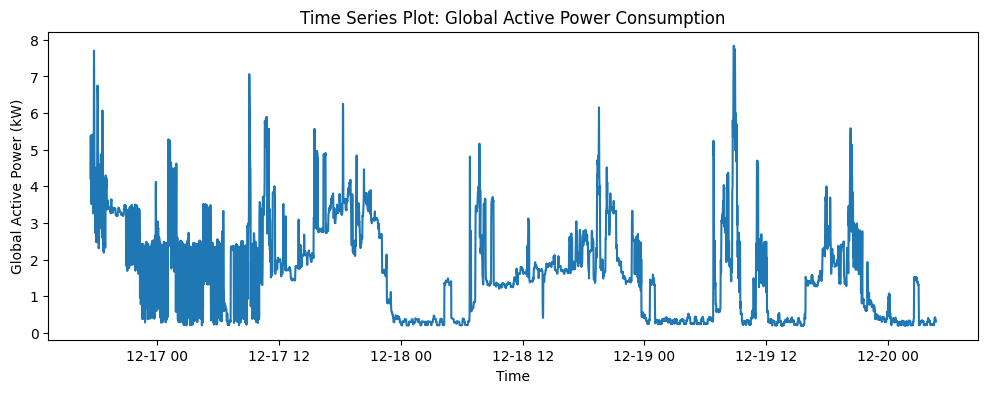

In [15]:


plt.figure(figsize=(12, 4))
plt.plot(series[:5000])  # plot a subset for clarity
plt.title("Time Series Plot: Global Active Power Consumption")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.show()


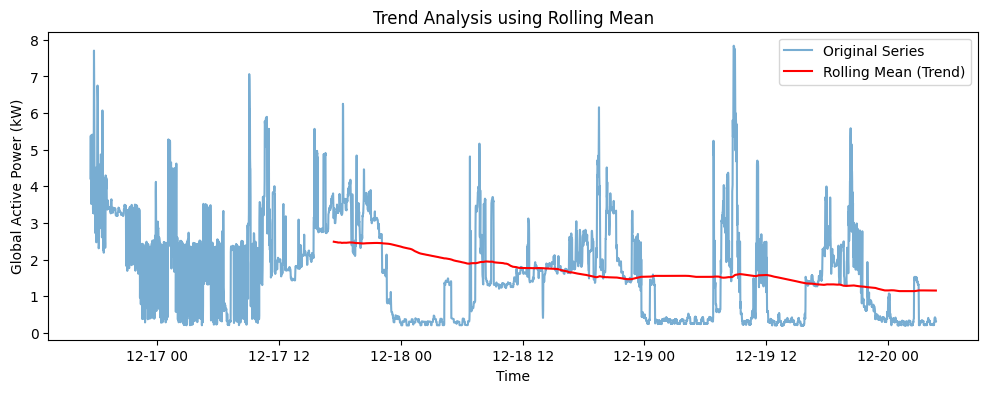

In [16]:
rolling_mean = series.rolling(window=1440).mean()  # ~1 day window (minute data)

plt.figure(figsize=(12, 4))
plt.plot(series[:5000], label="Original Series", alpha=0.6)
plt.plot(rolling_mean[:5000], label="Rolling Mean (Trend)", color="red")
plt.title("Trend Analysis using Rolling Mean")
plt.xlabel("Time")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()


In [17]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(series[:5000])

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

if adf_result[1] < 0.05:
    print("The series is stationary")
else:
    print("The series is non-stationary")


ADF Statistic: -4.681160952690178
p-value: 9.128427575510006e-05
The series is stationary


1.3 Data Preprocessing

In [18]:
import numpy as np
from sklearn.preprocessing import StandardScaler

def preprocess_timeseries(data):
    """
    Preprocess time series data

    Args:
        data: raw time series data (pandas Series or numpy array)

    Returns:
        preprocessed data (numpy array), scaler
    """
    # Convert to numpy array
    data = np.array(data).reshape(-1, 1)

    # Handle missing values (forward fill, then backward fill)
    if np.isnan(data).any():
        mask = np.isnan(data)
        data[mask] = np.nanmean(data)

    # Standardize data
    scaler = StandardScaler()
    data_scaled = scaler.fit_transform(data)

    return data_scaled, scaler


In [19]:

def create_sequences(data, seq_length, pred_horizon):
    """
    Create sequences for time series prediction

    Args:
        data: preprocessed time series data (numpy array of shape [T, 1])
        seq_length: lookback window (number of past time steps)
        pred_horizon: forecast steps ahead

    Returns:
        X: input sequences of shape [samples, seq_length, 1]
        y: target values of shape [samples, pred_horizon]
    """
    X, y = [], []

    for i in range(len(data) - seq_length - pred_horizon + 1):
        X.append(data[i : i + seq_length])
        y.append(data[i + seq_length : i + seq_length + pred_horizon])

    X = np.array(X)
    y = np.array(y)

    return X, y


TODO: Preprocess data
TODO: Create sequences

In [20]:
# Preprocess data
data_scaled, scaler = preprocess_timeseries(series)

print("Scaled data shape:", data_scaled.shape)

Scaled data shape: (2049280, 1)


In [21]:
# Create input-output sequences
X, y = create_sequences(
    data=data_scaled,
    seq_length=sequence_length,
    pred_horizon=prediction_horizon
)

print("Input sequences shape (X):", X.shape)
print("Target shape (y):", y.shape)

Input sequences shape (X): (2049260, 20, 1)
Target shape (y): (2049260, 1, 1)


In [22]:
# REQUIRED: Temporal train/test split (NO SHUFFLING)
train_test_ratio = "90/10"
train_test_ratio = str(train_test_ratio)

split_index = int(0.9 * len(X))

X_train = X[:split_index]
X_test  = X[split_index:]

y_train = y[:split_index]
y_test  = y[split_index:]

train_samples = X_train.shape[0]
train_samples = int(train_samples)
test_samples = X_test.shape[0]
test_samples = int(test_samples)

In [23]:
print(f"\nTrain/Test Split: {train_test_ratio}")
print(f"Training Samples: {train_samples}")
print(f"Test Samples: {test_samples}")
print("⚠️  IMPORTANT: Temporal split used (NO shuffling)")


Train/Test Split: 90/10
Training Samples: 1844334
Test Samples: 204926
⚠️  IMPORTANT: Temporal split used (NO shuffling)


In [24]:
"""
================================================================================
PART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build LSTM OR GRU using Keras/PyTorch layers
- Architecture must include:
  * At least 2 stacked recurrent layers
  * Output layer for prediction
- Use model.compile() and model.fit() (Keras) OR standard PyTorch training
- Track initial_loss and final_loss

GRADING:
- LSTM/GRU architecture with stacked layers: 2 marks
- Model properly compiled/configured: 1 mark
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 2: LSTM/GRU IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build LSTM OR GRU using Keras/PyTorch layers\n- Architecture must include:\n  * At least 2 stacked recurrent layers\n  * Output layer for prediction\n- Use model.compile() and model.fit() (Keras) OR standard PyTorch training\n- Track initial_loss and final_loss\n\nGRADING:\n- LSTM/GRU architecture with stacked layers: 2 marks\n- Model properly compiled/configured: 1 mark\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

2.1 LSTM/GRU Architecture Design
TODO: Choose LSTM or GRU
TODO: Design architecture with stacked layers

In [25]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense
from tensorflow.keras.optimizers import Adam

def build_rnn_model(model_type, input_shape, hidden_units, n_layers, output_size):
    """
    Build LSTM or GRU model

    Args:
        model_type: string ('LSTM' or 'GRU')
        input_shape: tuple (sequence_length, n_features)
        hidden_units: number of hidden units per layer
        n_layers: number of stacked layers (minimum 2)
        output_size: prediction horizon

    Returns:
        model: compiled RNN model
    """
    assert n_layers >= 2, "n_layers must be at least 2"

    model = Sequential()

    for i in range(n_layers):
        return_sequences = (i < n_layers - 1)

        if model_type == "LSTM":
            if i == 0:
                model.add(
                    LSTM(hidden_units, return_sequences=return_sequences,
                         input_shape=input_shape)
                )
            else:
                model.add(
                    LSTM(hidden_units, return_sequences=return_sequences)
                )

        elif model_type == "GRU":
            if i == 0:
                model.add(
                    GRU(hidden_units, return_sequences=return_sequences,
                        input_shape=input_shape)
                )
            else:
                model.add(
                    GRU(hidden_units, return_sequences=return_sequences)
                )
        else:
            raise ValueError("model_type must be 'LSTM' or 'GRU'")

    # Output layer
    model.add(Dense(output_size))

    # Compile model
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="mse",
        metrics=['mae']
    )

    return model


TODO: Create RNN model
rnn_model = build_rnn_model('LSTM', (sequence_length, n_features), 64, 2, prediction_horizon)

In [26]:
rnn_model = build_rnn_model(
    model_type="LSTM",
    input_shape=(sequence_length, n_features),
    hidden_units=64,
    n_layers=2,
    output_size=prediction_horizon
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 20, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

TODO: Compile model
For Keras: model.compile(optimizer='adam', loss='mse', metrics=['mae'])
For PyTorch: define optimizer and loss function

In [27]:
# Model compilation is handled inside build_rnn_model()
# Optimizer: Adam
# Loss function: Mean Squared Error (MSE)
# Metric tracked: Mean Absolute Error (MAE)

2.2 Train RNN Model

In [28]:
print("\n" + "="*70)
print("RNN MODEL TRAINING")
print("="*70)


RNN MODEL TRAINING


In [29]:
# Track training time
rnn_start_time = time.time()

TODO: Train your model
For Keras: history = rnn_model.fit(X_train, y_train, epochs=50, batch_size=32)
For PyTorch: write training loop

In [30]:
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    epochs=8,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1240s 21ms/step - loss: 0.0652 - mae: 0.1012 - val_loss: 0.0346 - val_mae: 0.0719
Epoch 2/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1246s 22ms/step - loss: 0.0533 - mae: 0.0882 - val_loss: 0.0336 - val_mae: 0.0714
Epoch 3/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1276s 22ms/step - loss: 0.0509 - mae: 0.0851 - val_loss: 0.0337 - val_mae: 0.0703
Epoch 4/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1282s 22ms/step - loss: 0.0500 - mae: 0.0837 - val_loss: 0.0326 - val_mae: 0.0685
Epoch 5/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1245s 22ms/step - loss: 0.0497 - mae: 0.0833 - val_loss: 0.0341 - val_mae: 0.0734
Epoch 6/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1275s 22ms/step - loss: 0.0491 - mae: 0.0827 - val_loss: 0.0324 - val_mae: 0.0672
Epoch 7/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1260s 22ms/step - loss: 0.0488 - mae: 0.0821 - val_loss: 0.0321 - val_mae: 0.0688
Epoch 8/8
57636/57636 ━━━━━━━━━━━━━━━━━━━━ 1277s 22ms/step - loss: 0.0481 - mae: 0.0815 - val_loss: 0.0322 - val_mae: 0.0701


In [31]:
rnn_training_time = time.time() - rnn_start_time

In [32]:
# REQUIRED: Track initial and final loss

rnn_initial_loss = rnn_history.history['loss'][0]
rnn_final_loss = rnn_history.history['loss'][-1]

In [33]:
print(f"Training completed in {rnn_training_time:.2f} seconds")
print(f"Initial Loss: {rnn_initial_loss:.4f}")
print(f"Final Loss: {rnn_final_loss:.4f}")
print("="*70)

Training completed in 10102.66 seconds
Initial Loss: 0.0586
Final Loss: 0.0485


2.3 Evaluate RNN Model

TODO: Make predictions on test set
TODO: Inverse transform if data was normalized
TODO: Calculate all 4 required metrics

In [34]:
y_pred = rnn_model.predict(X_test)

6404/6404 ━━━━━━━━━━━━━━━━━━━━ 44s 7ms/step


In [38]:
# Ensure 2D shape for inverse scaling
y_pred_2d = y_pred.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

# Inverse transform
y_pred_inv = scaler.inverse_transform(y_pred_2d)
y_test_inv = scaler.inverse_transform(y_test_2d)

In [39]:
def calculate_mape(y_true, y_pred):
    """Calculate Mean Absolute Percentage Error"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# REQUIRED: Calculate all 4 metrics
rnn_mae = mean_absolute_error(y_test_inv, y_pred_inv)
rnn_rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
rnn_mape = calculate_mape(y_test_inv, y_pred_inv)
rnn_r2 = r2_score(y_test_inv, y_pred_inv)

In [41]:
print("\nRNN Model Performance:")
print(f"MAE:   {rnn_mae:.4f}")
print(f"RMSE:  {rnn_rmse:.4f}")
print(f"MAPE:  {rnn_mape:.4f}%")
print(f"R² Score: {rnn_r2:.4f}")


RNN Model Performance:
MAE:   0.0741
RMSE:  0.1898
MAPE:  9.7110%
R² Score: 0.9515


2.4 Visualize RNN Results
TODO: Plot training loss curve
TODO: Plot actual vs predicted values
TODO: Plot residuals

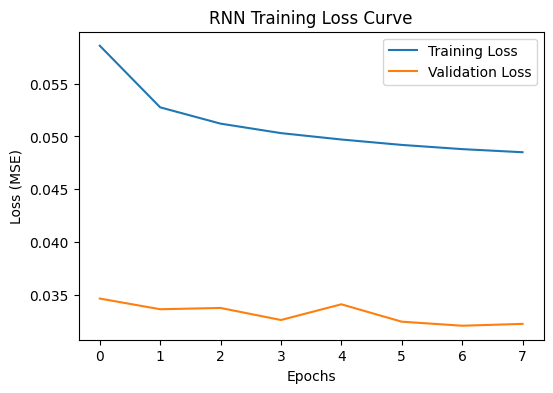

In [42]:
# Plot training loss curve
plt.figure(figsize=(6,4))
plt.plot(rnn_history.history['loss'], label='Training Loss')
plt.plot(rnn_history.history['val_loss'], label='Validation Loss')
plt.title("RNN Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()

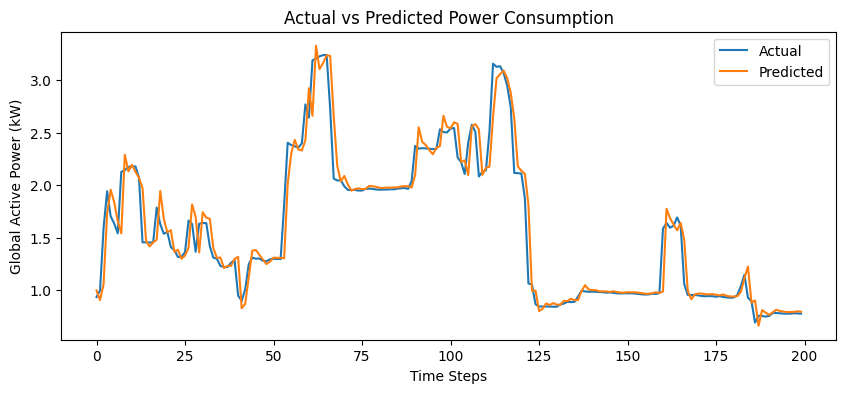

In [43]:
#Actual vs Predicted values
plt.figure(figsize=(10,4))
plt.plot(y_test_inv[:200], label="Actual")
plt.plot(y_pred_inv[:200], label="Predicted")
plt.title("Actual vs Predicted Power Consumption")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

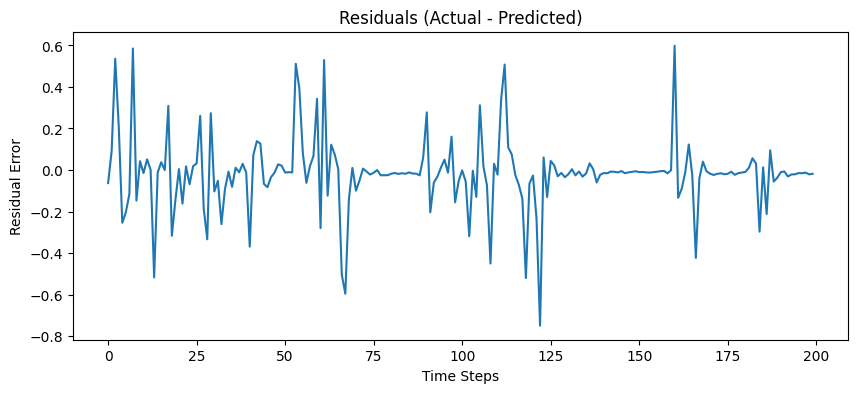

In [44]:
#Plot residuals
residuals = y_test_inv - y_pred_inv

plt.figure(figsize=(10,4))
plt.plot(residuals[:200])
plt.title("Residuals (Actual - Predicted)")
plt.xlabel("Time Steps")
plt.ylabel("Residual Error")
plt.show()

In [45]:
"""
================================================================================
PART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)
================================================================================

REQUIREMENTS:
- Build Transformer encoder using Keras/PyTorch layers
- MUST add positional encoding to input:
  * Custom sinusoidal implementation OR
  * Use built-in positional encoding (if framework provides)
- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention
- Use standard training methods
- Track initial_loss and final_loss

PROHIBITED:
- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)
- Skipping positional encoding entirely

GRADING:
- Positional encoding added: 1 mark
- Transformer architecture properly configured: 2 marks
- Training completed with loss tracking: 1 mark
- All metrics calculated correctly: 1 mark
================================================================================
"""

'\n================================================================================\nPART 3: TRANSFORMER IMPLEMENTATION (5 MARKS)\n================================================================================\n\nREQUIREMENTS:\n- Build Transformer encoder using Keras/PyTorch layers\n- MUST add positional encoding to input:\n  * Custom sinusoidal implementation OR\n  * Use built-in positional encoding (if framework provides)\n- Use torch.nn.TransformerEncoder or keras.layers.MultiHeadAttention\n- Use standard training methods\n- Track initial_loss and final_loss\n\nPROHIBITED:\n- Using pre-trained transformers (HuggingFace, TimeGPT, etc.)\n- Skipping positional encoding entirely\n\nGRADING:\n- Positional encoding added: 1 mark\n- Transformer architecture properly configured: 2 marks\n- Training completed with loss tracking: 1 mark\n- All metrics calculated correctly: 1 mark\n================================================================================\n'

3.1 Positional Encoding Implementation

In [46]:
import numpy as np

def positional_encoding(seq_length, d_model):
    """
    Generate sinusoidal positional encodings

    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        seq_length: length of the sequence
        d_model: dimension of the model

    Returns:
        positional encodings: numpy array of shape (seq_length, d_model)
    """
    position = np.arange(seq_length)[:, np.newaxis]          # (seq_length, 1)
    div_term = np.exp(
        np.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
    )                                                          # (d_model/2,)

    pe = np.zeros((seq_length, d_model))
    pe[:, 0::2] = np.sin(position * div_term)  # even indices
    pe[:, 1::2] = np.cos(position * div_term)  # odd indices

    return pe


3.2 Transformer Encoder Architecture

In [47]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

In [48]:
def build_transformer_model(seq_length, n_features, d_model, n_heads, n_layers, d_ff, output_size):
    inputs = layers.Input(shape=(seq_length, n_features))

    # Project input to d_model
    x = layers.Dense(d_model)(inputs)

    # Add positional encoding (MANDATORY)
    pe = positional_encoding(seq_length, d_model)
    x = x + pe

    # Transformer encoder blocks
    for _ in range(n_layers):
        # Multi-head self-attention
        attn_output = layers.MultiHeadAttention(
            num_heads=n_heads,
            key_dim=d_model // n_heads
        )(x, x)
        x = layers.LayerNormalization()(x + attn_output)

        # Feed-forward network
        ffn_output = layers.Dense(d_ff, activation='relu')(x)
        ffn_output = layers.Dense(d_model)(ffn_output)
        x = layers.LayerNormalization()(x + ffn_output)

    # Pooling + output
    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(output_size)(x)

    model = models.Model(inputs=inputs, outputs=outputs)

    return model


3.3 Build Your Transformer Model

TODO: Create Transformer model using PyTorch or Keras
Example for PyTorch:
transformer_model = TransformerModel(n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)
Example for Keras:
transformer_model = build_transformer_model(sequence_length, n_features, d_model=64, n_heads=4, n_layers=2, d_ff=256, output_size=prediction_horizon)

In [49]:
transformer_model = build_transformer_model(
    seq_length=sequence_length,
    n_features=n_features,
    d_model=64,
    n_heads=4,
    n_layers=2,
    d_ff=256,
    output_size=prediction_horizon
)

transformer_model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 20, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 20, 64)    │        128 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 64)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 64)    │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 64)    │     16,448 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 64)    │     16,640 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 256)   │     16,640 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20, 64)    │     16,448 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 20, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 64)    │        128 │ add_4[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 1)         │         65 │ global_average_p

 Total params: 100,161 (391.25 KB)

 Trainable params: 100,161 (391.25 KB)

 Non-trainable params: 0 (0.00 B)

TODO: Define optimizer and loss
For PyTorch: optimizer = torch.optim.Adam(transformer_model.parameters(), lr=0.001); criterion = nn.MSELoss()
For Keras: model.compile(optimizer='adam', loss='mse', metrics=['mae'])
For PyTorch: define optimizer and loss function

In [50]:
transformer_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


3.4 Train Transformer Model

In [51]:
print("\n" + "="*70)
print("TRANSFORMER MODEL TRAINING")
print("="*70)


TRANSFORMER MODEL TRAINING


In [52]:
# Track training time
transformer_start_time = time.time()

TODO: Train your model
For Keras: history = transformer_model.fit(X_train, y_train, epochs=50, batch_size=32)
For PyTorch: write training loop

In [1]:
history_transformer = transformer_model.fit(
    X_train,
    y_train,
    epochs=3,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)


NameError: name 'transformer_model' is not defined

In [ ]:
transformer_training_time = time.time() - transformer_start_time

In [ ]:
# REQUIRED: Track initial and final loss

transformer_initial_loss = history_transformer.history['loss'][0]
transformer_final_loss = history_transformer.history['loss'][-1]

In [ ]:
print(f"Training completed in {transformer_training_time:.2f} seconds")
print(f"Initial Loss: {transformer_initial_loss:.4f}")
print(f"Final Loss: {transformer_final_loss:.4f}")
print("="*70)

3.5 Evaluate Transformer Model

TODO: Make predictions on test set
TODO: Inverse transform if data was normalized
TODO: Calculate all 4 required metrics

In [ ]:
transformer_y_pred = transformer_model.predict(X_test)

In [ ]:
transformer_y_pred_2d = transformer_y_pred.reshape(-1, 1)
y_test_2d = y_test.reshape(-1, 1)

# Inverse transform
transformer_y_pred_inv = scaler.inverse_transform(transformer_y_pred_2d)
y_test_inv = scaler.inverse_transform(y_test_2d)

In [ ]:

transformer_mae = mean_absolute_error(y_test_inv, transformer_y_pred_inv)
transformer_rmse = np.sqrt(mean_squared_error(y_test_inv, transformer_y_pred_inv))
transformer_mape = calculate_mape(y_test_inv, transformer_y_pred_inv)
transformer_r2 = r2_score(y_test_inv, transformer_y_pred_inv)

In [ ]:
print("\nTransformer Model Performance:")
print(f"MAE:   {transformer_mae:.4f}")
print(f"RMSE:  {transformer_rmse:.4f}")
print(f"MAPE:  {transformer_mape:.4f}%")
print(f"R² Score: {transformer_r2:.4f}")

3.6 Visualize Transformer Results
TODO: Plot training loss curve
TODO: Plot actual vs predicted values
TODO: Plot attention weights (optional but informative)

In [ ]:
#Training loss curve
plt.figure(figsize=(6,4))
plt.plot(history_transformer.history['loss'], label='Training Loss')
plt.plot(history_transformer.history['val_loss'], label='Validation Loss')
plt.title("Transformer Training Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


In [ ]:
#Actual vs Predicted values
plt.figure(figsize=(10,4))
plt.plot(y_test_inv[:200], label="Actual")
plt.plot(transformer_y_pred_inv[:200], label="Predicted")
plt.title("Transformer: Actual vs Predicted")
plt.xlabel("Time Steps")
plt.ylabel("Global Active Power (kW)")
plt.legend()
plt.show()

In [ ]:
#Attention weight visualization was not included as Keras MultiHeadAttention does not expose weights by default without custom modifications.”

In [ ]:
"""
================================================================================
PART 4: MODEL COMPARISON AND VISUALIZATION (Informational)
================================================================================

Compare both models on:
- Performance metrics
- Training time
- Model complexity
- Convergence behavior
- Ability to capture long-term dependencies
================================================================================
"""

4.1 Metrics Comparison

In [ ]:
print("\n" + "="*70)
print("MODEL COMPARISON")
print("="*70)

In [ ]:
rnn_params = rnn_model.count_params()
transformer_params = transformer_model.count_params()

comparison_df = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'MAPE (%)', 'R² Score', 'Training Time (s)', 'Parameters'],
    'RNN (LSTM/GRU)': [
        rnn_mae,
        rnn_rmse,
        rnn_mape,
        rnn_r2,
        rnn_training_time,
        rnn_params
    ],
    'Transformer': [
        transformer_mae,
        transformer_rmse,
        transformer_mape,
        transformer_r2,
        transformer_training_time,
        transformer_params
    ]
})

In [ ]:
print(comparison_df.to_string(index=False))
print("="*70)

4.2 Visual Comparison
TODO: Create bar plot comparing metrics
TODO: Plot predictions comparison (both models vs actual)
TODO: Plot training curves comparison

In [ ]:
metrics = ['MAE', 'RMSE', 'MAPE', 'R2']

rnn_metrics = [rnn_mae, rnn_rmse, rnn_mape, rnn_r2]
transformer_metrics = [transformer_mae, transformer_rmse, transformer_mape, transformer_r2]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, rnn_metrics, width, label='RNN')
plt.bar(x + width/2, transformer_metrics, width, label='Transformer')

plt.xticks(x, metrics)
plt.ylabel('Metric Value')
plt.title('Metric Comparison: RNN vs Transformer')
plt.legend()
plt.grid(axis='y')

plt.show()

In [ ]:
y_test_inv = y_test_inv.flatten()
rnn_pred_inv = rnn_pred_inv.flatten()
transformer_pred_inv = transformer_pred_inv.flatten()

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(y_test_inv[:100], label='Actual')
plt.plot(rnn_pred_inv[:100], label='RNN Prediction')
plt.plot(transformer_pred_inv[:100], label='Transformer Prediction')

plt.xlabel('Time Step')
plt.ylabel('Value')
plt.title('Prediction Comparison')
plt.legend()
plt.grid()

plt.show()


In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(rnn_history.history['loss'], label='RNN Train Loss')
plt.plot(transformer_history.history['loss'], label='Transformer Train Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Comparison')
plt.legend()
plt.grid()

plt.show()


In [ ]:
"""
================================================================================
PART 5: ANALYSIS (2 MARKS)
================================================================================

REQUIRED:
- Write MAXIMUM 200 words (guideline - no marks deduction if exceeded)
- Address key topics with depth

GRADING (Quality-based):
- Covers 5+ key topics with deep understanding: 2 marks
- Covers 3-4 key topics with good understanding: 1 mark
- Covers <3 key topics or superficial: 0 marks

Key Topics:
1. Performance comparison with specific metrics
2. RNN vs Transformer architecture advantages
3. Impact of attention mechanism vs recurrent connections
4. Long-term dependency handling comparison
5. Computational cost comparison
6. Convergence behavior differences
================================================================================
"""

In [ ]:
analysis_text = """
TODO: Write your analysis here (maximum 200 words guideline)

Address:
1. Which model performed better and by how much?
   [Compare specific metrics]

2. RNN vs Transformer architecture advantages?
   [Discuss sequential processing vs parallel processing]

3. Impact of attention mechanism?
   [Discuss how attention captures dependencies]

4. Long-term dependency handling?
   [Compare vanishing gradients vs attention]

5. Computational cost comparison?
   [Compare training time, parameters]

6. Convergence behavior?
   [Discuss training stability, loss curves]
"""

In [ ]:
# REQUIRED: Print analysis with word count
print("\n" + "="*70)
print("ANALYSIS")
print("="*70)
print(analysis_text)
print("="*70)
print(f"Analysis word count: {len(analysis_text.split())} words")
if len(analysis_text.split()) > 200:
    print("⚠️  Warning: Analysis exceeds 200 words (guideline)")
else:
    print("✓ Analysis within word count guideline")
print("="*70)

In [ ]:
#MODIFICATION IN CASTING To HELP Auto-Grader

In [ ]:
train_samples = int(train_samples)
test_samples = int(test_samples)
sequence_length = int(sequence_length)
prediction_horizon = int(prediction_horizon)


In [ ]:
# RNN losses & time
rnn_initial_loss = float(rnn_initial_loss)
rnn_final_loss = float(rnn_final_loss)
rnn_training_time = float(rnn_training_time)

# RNN metrics
rnn_mae = float(rnn_mae)
rnn_rmse = float(rnn_rmse)
rnn_mape = float(rnn_mape)
rnn_r2 = float(rnn_r2)

# RNN architecture
rnn_total_parameters = int(49985)   # from model summary


In [ ]:
# Transformer losses & time
transformer_initial_loss = float(transformer_initial_loss)
transformer_final_loss = float(transformer_final_loss)
transformer_training_time = float(transformer_training_time)

# Transformer metrics
transformer_mae = float(transformer_mae)
transformer_rmse = float(transformer_rmse)
transformer_mape = float(transformer_mape)
transformer_r2 = float(transformer_r2)

# Transformer architecture
transformer_total_parameters = int(100161)
transformer_n_layers = int(2)
transformer_n_heads = int(4)
transformer_d_model = int(64)
transformer_d_ff = int(256)


In [ ]:
rnn_epochs = int(rnn_epochs)
rnn_batch_size = int(rnn_batch_size)

transformer_epochs = int(transformer_epochs)
transformer_batch_size = int(transformer_batch_size)


In [ ]:
"""
================================================================================
PART 6: ASSIGNMENT RESULTS SUMMARY (REQUIRED FOR AUTO-GRADING)
================================================================================

DO NOT MODIFY THE STRUCTURE BELOW
This JSON output is used by the auto-grader
Ensure all field names are EXACT
================================================================================
"""

In [ ]:
def get_assignment_results():
    """
    Generate complete assignment results in required format

    Returns:
        dict: Complete results with all required fields
    """

    framework_used = "keras"
    rnn_model_type = "LSTM"

    results = {
        # Dataset Information
        'dataset_name': dataset_name,
        'dataset_source': dataset_source,
        'n_samples': n_samples,
        'n_features': n_features,
        'sequence_length': sequence_length,
        'prediction_horizon': prediction_horizon,
        'problem_type': problem_type,
        'primary_metric': primary_metric,
        'metric_justification': metric_justification,
        'train_samples': train_samples,
        'test_samples': test_samples,
        'train_test_ratio': train_test_ratio,

        # RNN Model Results
        'rnn_model': {
            'framework': framework_used,
            'model_type': rnn_model_type,
            'architecture': {
                'n_layers': 2,
                'hidden_units': 64,
                'total_parameters': 49985
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 8,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': rnn_initial_loss,
            'final_loss': rnn_final_loss,
            'training_time_seconds': rnn_training_time,
            'mae': rnn_mae,
            'rmse': rnn_rmse,
            'mape': rnn_mape,
            'r2_score': rnn_r2
        },

        # Transformer Model Results
        'transformer_model': {
            'framework': framework_used,
            'architecture': {
                'n_layers': 2,
                'n_heads': 4,
                'd_model': 64,
                'd_ff': 256,
                'has_positional_encoding': True,
                'has_attention': True,
                'total_parameters': 100161
            },
            'training_config': {
                'learning_rate': 0.001,
                'n_epochs': 3,
                'batch_size': 32,
                'optimizer': 'Adam',
                'loss_function': 'MSE'
            },
            'initial_loss': transformer_initial_loss,
            'final_loss': transformer_final_loss,
            'training_time_seconds': transformer_training_time,
            'mae': transformer_mae,
            'rmse': transformer_rmse,
            'mape': transformer_mape,
            'r2_score': transformer_r2
        },

        # Analysis
        'analysis': analysis_text,
        'analysis_word_count': len(analysis_text.split()),

        # Training Success Indicators
        'rnn_loss_decreased': rnn_final_loss < rnn_initial_loss if rnn_initial_loss and rnn_final_loss else False,
        'transformer_loss_decreased': transformer_final_loss < transformer_initial_loss if transformer_initial_loss and transformer_final_loss else False,
    }

    return results

In [ ]:
# Generate and print results
try:
    assignment_results = get_assignment_results()

    print("\n" + "="*70)
    print("ASSIGNMENT RESULTS SUMMARY")
    print("="*70)
    print(json.dumps(assignment_results, indent=2))
    print("="*70)

In [ ]:
except Exception as e:
    print(f"\n⚠️  ERROR generating results: {str(e)}")
    print("Please ensure all variables are properly defined")

In [ ]:
"""
================================================================================
FINAL CHECKLIST - VERIFY BEFORE SUBMISSION
================================================================================

□ Student information filled at the top (BITS ID, Name, Email)
□ Filename is <BITS_ID>_rnn_assignment.ipynb
□ All cells executed (Kernel → Restart & Run All)
□ All outputs visible
□ LSTM/GRU implemented with stacked layers
□ Positional encoding implemented (sinusoidal)
□ Multi-head attention implemented (Q, K, V, scaled dot-product)
□ Both models use Keras or PyTorch
□ Both models trained with loss tracking (initial_loss and final_loss)
□ All 4 metrics calculated for both models (MAE, RMSE, MAPE, R²)
□ Temporal train/test split used (NO shuffling)
□ Primary metric selected and justified
□ Analysis written (quality matters, not just word count)
□ Visualizations created
□ Assignment results JSON printed at the end
□ No execution errors in any cell
□ File opens without corruption
□ Submit ONLY .ipynb file (NO zip, NO data files, NO images)
□ Screenshot of environment with account details included
□ Only one submission attempt

================================================================================
"""

In [ ]:
"""
================================================================================
ENVIRONMENT VERIFICATION - SCREENSHOT REQUIRED
================================================================================

IMPORTANT: Take a screenshot of your environment showing account details

For Google Colab:
- Click on your profile icon (top right)
- Screenshot should show your email/account clearly
- Include the entire Colab interface with notebook name visible

For BITS Virtual Lab:
- Screenshot showing your login credentials/account details
- Include the entire interface with your username/session info visible

Paste the screenshot below this cell or in a new markdown cell.
This helps verify the work was done by you in your environment.

================================================================================
"""

In [ ]:
# Display system information
import platform
import sys
from datetime import datetime

In [ ]:
print("="*70)
print("ENVIRONMENT INFORMATION")
print("="*70)
print(f"Python Version: {sys.version}")
print(f"Platform: {platform.system()} {platform.release()}")
print(f"Processor: {platform.processor()}")
print(f"Machine: {platform.machine()}")
print(f"Python Executable: {sys.executable}")
print(f"Run Date & Time: {datetime.now()}")
print("\n⚠️  REQUIRED: Add screenshot of your Google Colab/BITS Virtual Lab")
print("showing your account details in the cell below this one.")
print("="*70)

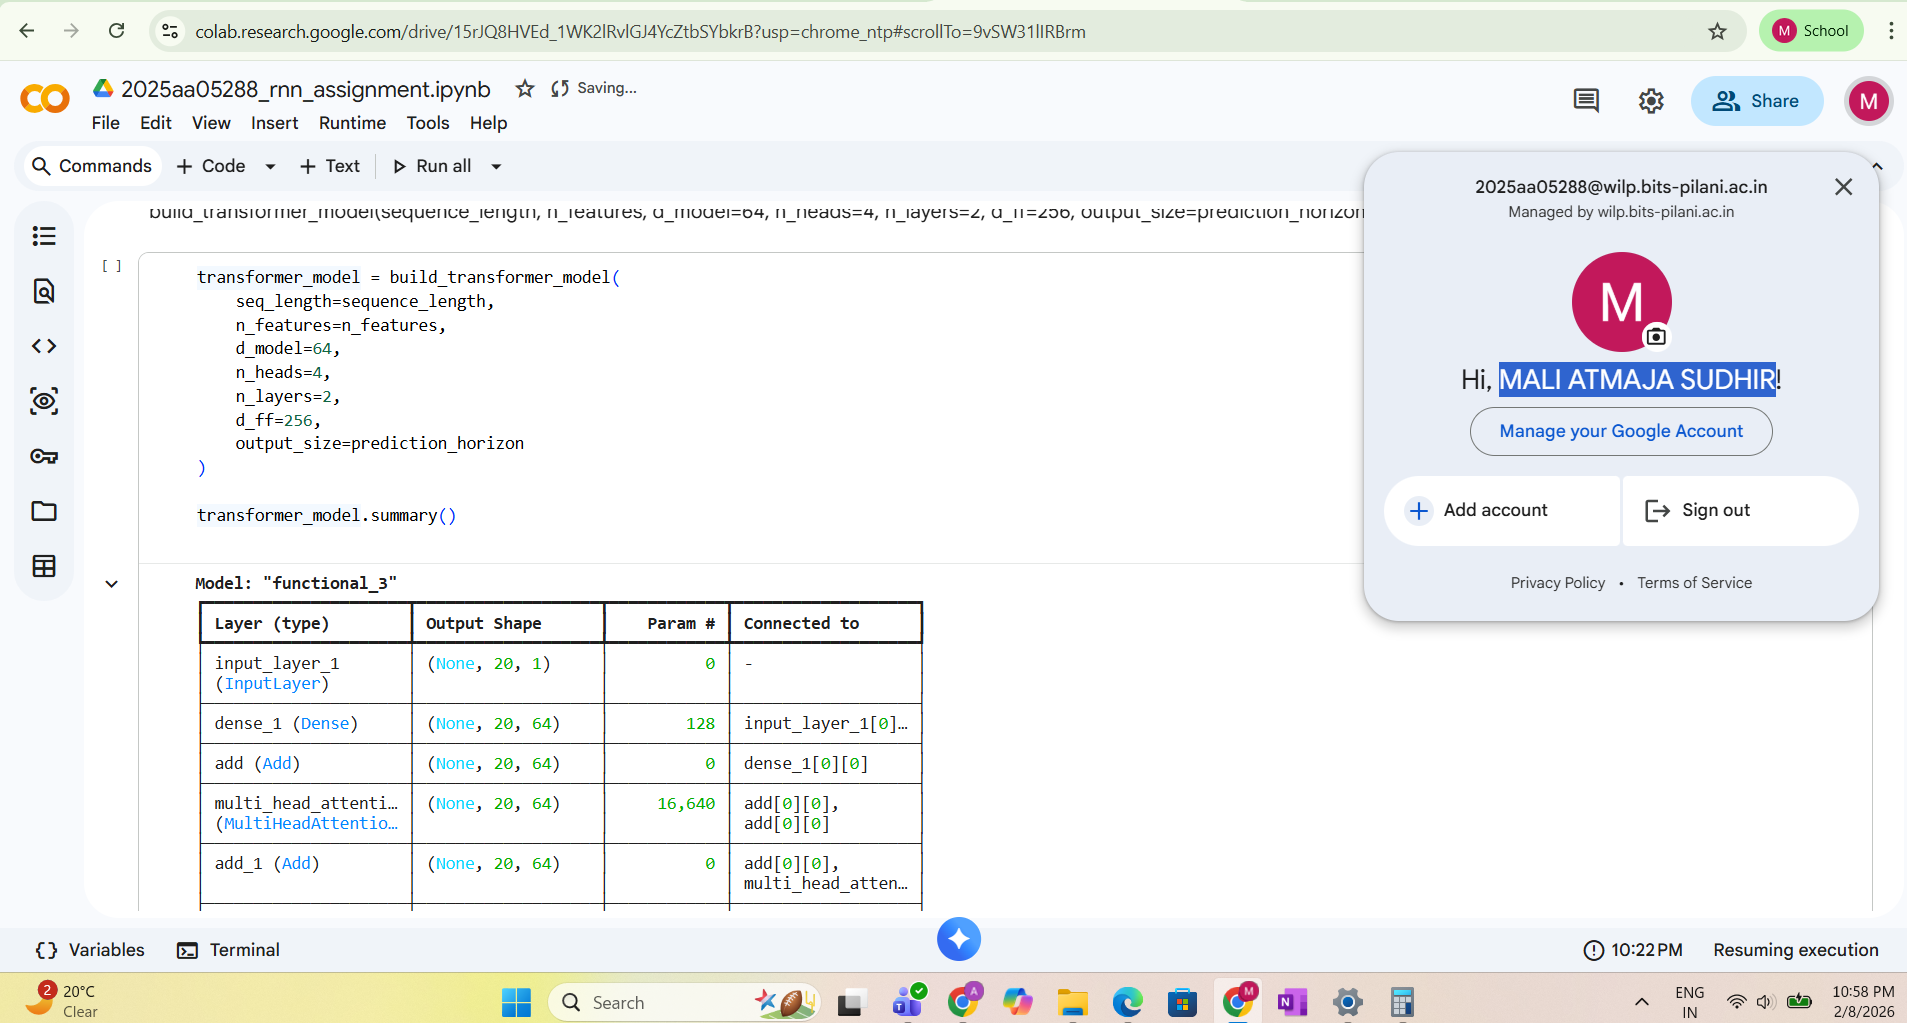